# Notebook 03: Paralelismo, Benchmarks y Patrones Avanzados

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sonder-art/fdd_p26/blob/main/clase/16_computo/code/03_paralelismo_benchmarks.ipynb)

**Módulo 16 — Clase 3**

Este notebook acompaña los archivos `04b_asyncio_patrones.md`, `05_paralelismo.md`, `06_librerias_y_decision.md`.

Secciones **** se trabajan durante la sesión.  
Secciones **** se completan después.

---

In [ ]:
import asyncio
import time
import threading
import os
import sys
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor

print(f'Python {sys.version}')
print(f'CPU cores disponibles: {os.cpu_count()}')

## Sección 1: create_task vs gather — trabajo intermedio "gratis"

**Hipótesis:** con `create_task`, podemos ejecutar trabajo independiente mientras una tarea espera.
El trabajo intermedio debe ocurrir "gratis" — durante el wait de la tarea lanzada.

In [ ]:
async def tarea_io(nombre: str, duracion: float) -> str:
    """Simula I/O-bound: wait(τᵢ) ≠ ∅"""
    await asyncio.sleep(duracion)
    return f"{nombre} completada"

def trabajo_cpu_ligero(n: int) -> int:
    """Trabajo CPU-bound ligero: exec(τⱼ) mientras τᵢ espera"""
    return sum(range(n))

# --- Comparación: gather vs create_task ---

# gather: barrera — espera TODAS antes de continuar
print("=== gather: barrera ===")
t0 = time.perf_counter()
r1, r2 = await asyncio.gather(
    tarea_io("A", 1.0),
    tarea_io("B", 1.0),
)
t_gather = time.perf_counter() - t0
print(f"Resultados: {r1}, {r2}")
print(f"Tiempo: {t_gather:.2f}s (esperado ~1s)")
print()

# create_task: lanzar y continuar con trabajo intermedio
print("=== create_task + trabajo intermedio ===")
t0 = time.perf_counter()

# ① Lanzar τᵢ en background
tarea_a = asyncio.create_task(tarea_io("A", 1.0))

# ② Trabajo independiente DURANTE el wait de A
t_trabajo = time.perf_counter()
resultado_cpu = trabajo_cpu_ligero(5_000_000)   # ~200ms de CPU
t_trabajo = time.perf_counter() - t_trabajo
print(f"  Trabajo CPU completado en {t_trabajo:.2f}s (durante wait de A)")

# ③ Punto de dependencia: necesitamos el resultado de A
resultado_a = await tarea_a
t_create_task = time.perf_counter() - t0

print(f"  {resultado_a}")
print(f"Tiempo total: {t_create_task:.2f}s (esperado ~max(1s, tiempo_cpu))")
print()
print(f"Observa: el trabajo CPU ({t_trabajo:.2f}s) fue 'gratis' — ocurrió durante el wait de A.")
print(f"Sin create_task, hubiera sumado {1.0 + t_trabajo:.2f}s en lugar de {t_create_task:.2f}s")

=== gather: barrera ===
Resultados: A completada, B completada
Tiempo: 1.00s (esperado ~1s)

=== create_task + trabajo intermedio ===
  Trabajo CPU completado en 0.12s (durante wait de A)
  A completada
Tiempo total: 1.13s (esperado ~max(1s, tiempo_cpu))

Observa: el trabajo CPU (0.12s) fue 'gratis' — ocurrió durante el wait de A.
Sin create_task, hubiera sumado 1.12s en lugar de 1.13s


## Sección 2: as_completed — procesar resultados conforme llegan

Con tareas de **duración variable**, `gather` espera al más lento antes de procesar cualquier resultado.
`as_completed` permite procesar cada resultado tan pronto como está disponible.

In [ ]:
import random
import asyncio
import time

async def buscar_fuente(nombre: str, latencia: float) -> str:
    """Simula búsqueda en una fuente externa con latencia variable"""
    await asyncio.sleep(latencia)
    return f"resultado de {nombre} (tardó {latencia:.1f}s)"

fuentes = [
    ("Wikipedia", 0.5),
    ("ArXiv",     2.1),
    ("GitHub",    0.8),
    ("PubMed",    1.5),
    ("DuckDuck",  0.3),
]


# --- Con gather: espera el más lento ---
print("=== asyncio.gather: espera al más lento ===")
t0 = time.perf_counter()
resultados = await asyncio.gather(
      *[buscar_fuente(nombre, lat) for nombre, lat in fuentes]
  )
t_gather = time.perf_counter() - t0
print(f"Todos los resultados disponibles a los {t_gather:.2f}s")
for r in resultados:
    print(f"  {r}")
print()

# --- Con as_completed: procesar conforme llegan ---
print("=== asyncio.as_completed: procesa conforme llegan ===")
t0 = time.perf_counter()
tareas = [asyncio.create_task(buscar_fuente(n, l)) for n, l in fuentes]

orden_llegada = []
for tarea_completada in asyncio.as_completed(tareas):
    resultado = await tarea_completada
    t_llegada = time.perf_counter() - t0
    print(f"  t={t_llegada:.2f}s → {resultado}")
    orden_llegada.append(resultado)

print()
print("Observa: el orden de llegada es por latencia, no por orden de creación.")
print("El resultado más rápido (DuckDuck, 0.3s) llega primero aunque fue creado al final.")



=== asyncio.gather: espera al más lento ===
Todos los resultados disponibles a los 2.10s
  resultado de Wikipedia (tardó 0.5s)
  resultado de ArXiv (tardó 2.1s)
  resultado de GitHub (tardó 0.8s)
  resultado de PubMed (tardó 1.5s)
  resultado de DuckDuck (tardó 0.3s)

=== asyncio.as_completed: procesa conforme llegan ===
  t=0.30s → resultado de DuckDuck (tardó 0.3s)
  t=0.50s → resultado de Wikipedia (tardó 0.5s)
  t=0.80s → resultado de GitHub (tardó 0.8s)
  t=1.50s → resultado de PubMed (tardó 1.5s)
  t=2.10s → resultado de ArXiv (tardó 2.1s)

Observa: el orden de llegada es por latencia, no por orden de creación.
El resultado más rápido (DuckDuck, 0.3s) llega primero aunque fue creado al final.


---

## Sección 3: asyncio.Queue — productor-consumidor

Implementa el patrón productor-consumidor usando `asyncio.Queue`.

In [ ]:
# TAREA 3: Implementar el patrón productor-consumidor
#

# TODO: implementa `productor(queue, n)` y `worker(queue, nombre)`
# Hint: usa `await queue.put(item)` y `await queue.get()`
# No olvides el sentinel para terminar los workers

# TODO: lanza con asyncio.gather y mide tiempos con 1, 2, 3 workers

print("TODO: implementa el patrón productor-consumidor")

import asyncio
import time

N_PETICIONES = 10
RITMO_PRODUCCION = 0.5   # segundos entre peticiones
T_PROCESAMIENTO = 0.5    # segundos que tarda cada petición

async def productor(queue: asyncio.Queue, n: int, n_workers: int):
    """Genera n peticiones a ritmo de RITMO_PRODUCCION seg entre cada una."""
    for i in range(n):
        await queue.put(f"peticion-{i+1}")
        print(f"  [productor] encolada peticion-{i+1}")
        await asyncio.sleep(RITMO_PRODUCCION)

    # Sentinel: un None por cada worker para que sepan cuándo parar
    for _ in range(n_workers):
        await queue.put(None)

async def worker(queue: asyncio.Queue, nombre: str, resultados: list):
    """Consume peticiones de la cola hasta recibir el sentinel (None)."""
    while True:
        item = await queue.get()
        if item is None:          # sentinel → terminar
            queue.task_done()
            break
        t_inicio = time.perf_counter()
        await asyncio.sleep(T_PROCESAMIENTO)
        t_total = time.perf_counter() - t_inicio
        resultados.append((nombre, item, round(t_total, 3)))
        print(f"    [{nombre}] procesó {item} en {t_total:.3f}s")
        queue.task_done()

async def simular(n_workers: int) -> float:
    """Ejecuta la simulación completa y devuelve el tiempo total."""
    print(f"\n{'='*55}")
    print(f"  Simulación con {n_workers} worker(s)")
    print(f"{'='*55}")

    queue: asyncio.Queue = asyncio.Queue()
    resultados = []

    t_inicio = time.perf_counter()

    tareas_workers = [
        asyncio.create_task(worker(queue, f"worker-{i+1}", resultados))
        for i in range(n_workers)
    ]
    tarea_productor = asyncio.create_task(
        productor(queue, N_PETICIONES, n_workers)
    )

    await asyncio.gather(tarea_productor, *tareas_workers)

    t_total = time.perf_counter() - t_inicio
    print(f"\n  ✓ {len(resultados)} peticiones procesadas en {t_total:.2f}s")
    return t_total

async def main():
    tiempos = {}
    for n in [1, 2, 3]:
        tiempos[n] = await simular(n)

    print(f"\n{'='*55}")
    print("  RESUMEN COMPARATIVO")
    print(f"{'='*55}")
    print(f"  {'Workers':<10} {'Tiempo total':>14}  {'Ganancia vs 1':>14}")
    base = tiempos[1]
    for n, t in tiempos.items():
        ganancia = f"{base/t:.2f}x" if n > 1 else "—"
        print(f"  {n:<10} {t:>12.2f}s  {ganancia:>14}")

    print(f"\n  Producción: {N_PETICIONES} peticiones a 1/{RITMO_PRODUCCION}s")
    print(f"  Procesamiento: {T_PROCESAMIENTO}s / petición")
    print(f"  Cuellos de botella esperados:")
    t_produccion = N_PETICIONES * RITMO_PRODUCCION
    for n in [1, 2, 3]:
        t_proceso = (N_PETICIONES * T_PROCESAMIENTO) / n
        bottleneck = max(t_produccion, t_proceso)
        print(f"    {n} worker(s): max({t_produccion:.1f}s prod, "
              f"{t_proceso:.1f}s proc) ≈ {bottleneck:.1f}s")

asyncio.run(main())

TODO: implementa el patrón productor-consumidor

  Simulación con 1 worker(s)
  [productor] encolada peticion-1
  [productor] encolada peticion-2
    [worker-1] procesó peticion-1 en 0.501s
  [productor] encolada peticion-3
    [worker-1] procesó peticion-2 en 0.501s
  [productor] encolada peticion-4
    [worker-1] procesó peticion-3 en 0.501s
  [productor] encolada peticion-5
    [worker-1] procesó peticion-4 en 0.501s
  [productor] encolada peticion-6
    [worker-1] procesó peticion-5 en 0.501s
  [productor] encolada peticion-7
    [worker-1] procesó peticion-6 en 0.501s
  [productor] encolada peticion-8
    [worker-1] procesó peticion-7 en 0.501s
  [productor] encolada peticion-9
    [worker-1] procesó peticion-8 en 0.501s
  [productor] encolada peticion-10
    [worker-1] procesó peticion-9 en 0.501s
    [worker-1] procesó peticion-10 en 0.501s

  ✓ 10 peticiones procesadas en 5.01s

  Simulación con 2 worker(s)
  [productor] encolada peticion-1
  [productor] encolada peticion-2
   

## Sección 4: fire-and-forget — excepción silenciada vs tracked

In [3]:
# TAREA 4: Demostrar fire-and-forget con excepción silenciada
import asyncio
import logging

logging.basicConfig(level=logging.ERROR)
logger = logging.getLogger(__name__)

# ── Callback que inspecciona el future al terminar ──────────────────────────
def handle_task_result(future: asyncio.Future) -> None:
    """Se ejecuta automáticamente cuando la tarea termina (con o sin error)."""
    if future.cancelled():
        logger.error("La tarea fue cancelada")
    elif exc := future.exception():          # ← extrae la excepción si existe
        logger.error("Excepción capturada en tarea fire-and-forget: %s", exc, exc_info=exc)
    # Si no hay excepción, la tarea terminó bien — no hacemos nada

# ── Tarea que falla ─────────────────────────────────────────────────────────
async def tarea_que_falla():
    await asyncio.sleep(0.1)
    raise ValueError("¡Error en la tarea!")

# ── Main ────────────────────────────────────────────────────────────────────
async def main():
    # Anti-patrón ────────────────────────────────────────────────────────────
    print("=== Anti-patrón: fire-and-forget ===")
    t = asyncio.create_task(tarea_que_falla())
    await asyncio.sleep(0.5)
    print("No se vio ningún error — ¡la excepción fue silenciada!\n")

    # Patrón correcto ─────────────────────────────────────────────────────────
    print("=== Patrón correcto: fire-and-forget con callback ===")
    t = asyncio.create_task(tarea_que_falla())
    t.add_done_callback(handle_task_result)  # ← registra el callback
    await asyncio.sleep(0.5)
    print("El programa siguió corriendo Y el error fue registrado.")

asyncio.run(main())


RuntimeError: asyncio.run() cannot be called from a running event loop

## Sección 5: Benchmark asyncio vs threading — I/O-bound

Compara asyncio y ThreadPoolExecutor para tareas I/O-bound.
Ambos deberían funcionar — ¿cuál es más rápido y más simple?

In [5]:
import asyncio
import time
from concurrent.futures import ThreadPoolExecutor

# ── Versiones de la tarea ────────────────────────────────────────────────────

def io_bound_sync(duracion: float) -> str:
    time.sleep(duracion)
    return "resultado"

async def io_bound_async(duracion: float) -> str:
    await asyncio.sleep(duracion)   # simula aiohttp.get, asyncpg, etc.
    return "resultado"

N   = 20
DUR = 0.2

# ── ThreadPoolExecutor ───────────────────────────────────────────────────────

t0 = time.perf_counter()
with ThreadPoolExecutor(max_workers=N) as pool:
    futuros    = [pool.submit(io_bound_sync, DUR) for _ in range(N)]
    resultados = [f.result() for f in futuros]
t_thread = time.perf_counter() - t0

print(f"ThreadPoolExecutor ({N} workers): {t_thread:.2f}s  (esperado ~{DUR:.1f}s)")

# ── asyncio.gather ───────────────────────────────────────────────────────────

async def main() -> None:
    t0 = time.perf_counter()
    resultados = await asyncio.gather(
        *[io_bound_async(DUR) for _ in range(N)]
    )
    t_async = time.perf_counter() - t0
    print(f"asyncio.gather     ({N} tareas):  {t_async:.2f}s  (esperado ~{DUR:.1f}s)")

asyncio.run(main())

ThreadPoolExecutor (20 workers): 0.24s  (esperado ~0.2s)


RuntimeError: asyncio.run() cannot be called from a running event loop

## Sección 6: threading vs multiprocessing — CPU-bound con el GIL en números

Confirma empíricamente la predicción del GIL: threading no escala para CPU-bound, multiprocessing sí.

Secuencial (2 tareas): 4.28s  (baseline)

 Workers │  Threads (s) │  Speedup │  Processes (s) │  Speedup
────────────────────────────────────────────────────────────────
       1 │         0.99 │    4.34x │           0.80 │    5.38x
       2 │         0.98 │    4.35x │           1.07 │    3.99x
       4 │         1.93 │    2.22x │           2.15 │    1.99x
       2 │         1.00 │    4.29x │           1.08 │    3.97x


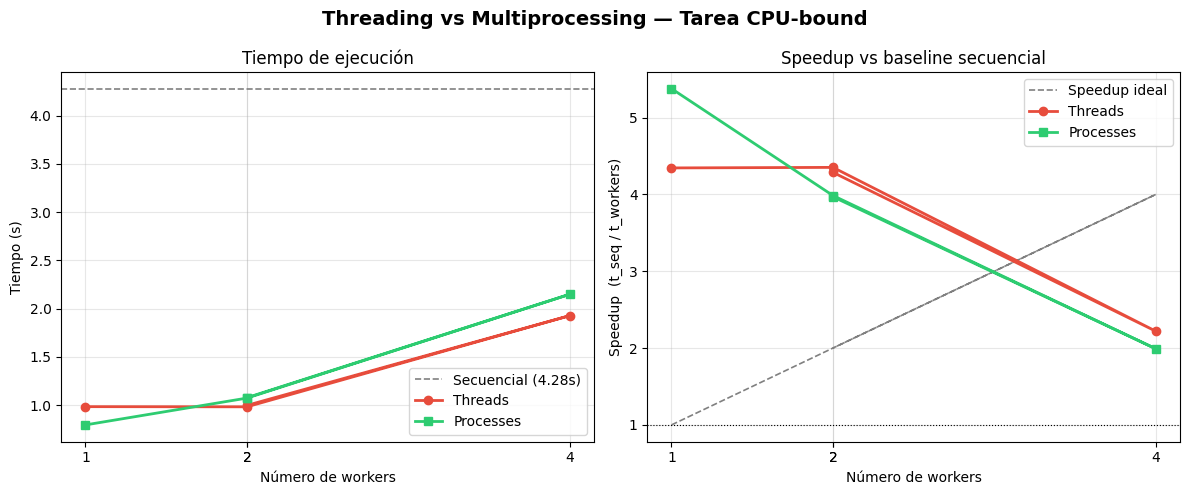


Gráfica guardada en benchmark_cpu.png


In [6]:
import os
import time
import threading
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Tarea CPU-bound (debe estar en nivel de módulo para pickle) ──────────────

def tarea_cpu(n: int) -> int:
    return sum(range(n))

# ── Configuración ────────────────────────────────────────────────────────────

N_TRABAJO    = 20_000_000
N_WORKERS_LIST = [1, 2, 4, os.cpu_count()]
n_baseline   = N_WORKERS_LIST[-1]   # número fijo de tareas en todas las pruebas

# ── Baseline secuencial ──────────────────────────────────────────────────────

t0    = time.perf_counter()
for _ in range(n_baseline):
    tarea_cpu(N_TRABAJO)
t_seq = time.perf_counter() - t0
print(f"Secuencial ({n_baseline} tareas): {t_seq:.2f}s  (baseline)\n")

# ── Benchmark genérico ───────────────────────────────────────────────────────

def benchmark_threads(n_workers: int) -> float:
    """n_workers threads corriendo tarea_cpu en paralelo (GIL los serializa)."""
    threads = [
        threading.Thread(target=tarea_cpu, args=(N_TRABAJO,))
        for _ in range(n_workers)
    ]
    t0 = time.perf_counter()
    for th in threads: th.start()
    for th in threads: th.join()
    return time.perf_counter() - t0

def benchmark_processes(n_workers: int) -> float:
    """n_workers procesos reales, cada uno con su propio intérprete."""
    t0 = time.perf_counter()
    with ProcessPoolExecutor(max_workers=n_workers) as pool:
        list(pool.map(tarea_cpu, [N_TRABAJO] * n_workers))
    return time.perf_counter() - t0

# ── Ejecutar benchmark ───────────────────────────────────────────────────────

resultados = {"workers": [], "threads": [], "processes": [],
              "speedup_th": [], "speedup_pr": []}

print(f"{'Workers':>8} │ {'Threads (s)':>12} │ {'Speedup':>8} │ "
      f"{'Processes (s)':>14} │ {'Speedup':>8}")
print("─" * 64)

for n in N_WORKERS_LIST:
    t_th = benchmark_threads(n)
    t_pr = benchmark_processes(n)
    sp_th = t_seq / t_th
    sp_pr = t_seq / t_pr

    resultados["workers"].append(n)
    resultados["threads"].append(t_th)
    resultados["processes"].append(t_pr)
    resultados["speedup_th"].append(sp_th)
    resultados["speedup_pr"].append(sp_pr)

    print(f"{n:>8} │ {t_th:>12.2f} │ {sp_th:>7.2f}x │ {t_pr:>14.2f} │ {sp_pr:>7.2f}x")

# ── Gráfica ──────────────────────────────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Threading vs Multiprocessing — Tarea CPU-bound", fontsize=14, fontweight="bold")

workers = resultados["workers"]

# Panel izquierdo: tiempos absolutos
ax1.axhline(t_seq, color="gray", linestyle="--", linewidth=1.2, label=f"Secuencial ({t_seq:.2f}s)")
ax1.plot(workers, resultados["threads"],   "o-", color="#e74c3c", linewidth=2, label="Threads")
ax1.plot(workers, resultados["processes"], "s-", color="#2ecc71", linewidth=2, label="Processes")
ax1.set_xlabel("Número de workers")
ax1.set_ylabel("Tiempo (s)")
ax1.set_title("Tiempo de ejecución")
ax1.legend()
ax1.xaxis.set_major_locator(ticker.FixedLocator(workers))
ax1.grid(alpha=0.3)

# Panel derecho: speedup
ideal = [n / workers[0] for n in workers]
ax2.plot(workers, ideal,                      "--", color="gray",    linewidth=1.2, label="Speedup ideal")
ax2.plot(workers, resultados["speedup_th"],  "o-", color="#e74c3c", linewidth=2,   label="Threads")
ax2.plot(workers, resultados["speedup_pr"],  "s-", color="#2ecc71", linewidth=2,   label="Processes")
ax2.axhline(1, color="black", linewidth=0.8, linestyle=":")
ax2.set_xlabel("Número de workers")
ax2.set_ylabel("Speedup  (t_seq / t_workers)")
ax2.set_title("Speedup vs baseline secuencial")
ax2.legend()
ax2.xaxis.set_major_locator(ticker.FixedLocator(workers))
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("benchmark_cpu.png", dpi=150)
plt.show()
print("\nGráfica guardada en benchmark_cpu.png")

## Sección 7: joblib vs ProcessPoolExecutor — misma tarea

In [7]:
import os
import time
from concurrent.futures import ProcessPoolExecutor

try:
    from joblib import Parallel, delayed
    JOBLIB_OK = True
except ImportError:
    print("joblib no instalado — pip install joblib")
    JOBLIB_OK = False

def tarea_cpu(n: int) -> int:
    return sum(range(n))

if JOBLIB_OK:
    datos  = list(range(1_000_000, 1_001_000))
    N_JOBS = 4

    t0 = time.perf_counter()
    with ProcessPoolExecutor(max_workers=N_JOBS) as pool:
        resultados_ppe = list(pool.map(tarea_cpu, datos))
    t_ppe = time.perf_counter() - t0
    print(f"ProcessPoolExecutor ({N_JOBS} workers): {t_ppe:.2f}s")

    t0 = time.perf_counter()
    resultados_jl = Parallel(n_jobs=N_JOBS)(delayed(tarea_cpu)(n) for n in datos)
    t_jl = time.perf_counter() - t0
    print(f"joblib.Parallel     ({N_JOBS} workers): {t_jl:.2f}s")

    assert resultados_ppe == resultados_jl, "resultados diferentes!"
    print("\nResultados idénticos: ✓")

    print("""
¿Cuándo preferir joblib?
- Necesitas paralelizar lambdas o closures (usa cloudpickle internamente)
- Trabajas con numpy: evita copiar arrays grandes con memory-map automático
- Quieres n_jobs=-1 para usar todos los CPUs sin calcular os.cpu_count()
- Ya tienes scikit-learn en el proyecto (joblib ya está incluido)

¿Cuándo quedarte con ProcessPoolExecutor?
- No quieres dependencias extra (es stdlib puro)
- Las funciones son simples y picklables sin problema
""")

ProcessPoolExecutor (4 workers): 31.98s
joblib.Parallel     (4 workers): 37.10s

Resultados idénticos: ✓

¿Cuándo preferir joblib?
- Necesitas paralelizar lambdas o closures (usa cloudpickle internamente)
- Trabajas con numpy: evita copiar arrays grandes con memory-map automático
- Quieres n_jobs=-1 para usar todos los CPUs sin calcular os.cpu_count()
- Ya tienes scikit-learn en el proyecto (joblib ya está incluido)

¿Cuándo quedarte con ProcessPoolExecutor?
- No quieres dependencias extra (es stdlib puro)
- Las funciones son simples y picklables sin problema



## Sección 8: Anti-patrón lambda (PicklingError)

In [8]:
from concurrent.futures import ProcessPoolExecutor
from functools import partial

# ── Anti-patrón: lambda no es picklable ─────────────────────────────────────

try:
    with ProcessPoolExecutor(max_workers=2) as pool:
        resultados = list(pool.map(lambda x: x**2, [1, 2, 3, 4]))
    print("¿Sin error? (puede pasar en algunos sistemas)")
    print(resultados)
except Exception as e:
    print(f"Error esperado: {type(e).__name__}: {e}")

# ── Fix 1: función a nivel de módulo ────────────────────────────────────────

def al_cuadrado(x: int) -> int:
    return x ** 2

with ProcessPoolExecutor(max_workers=2) as pool:
    resultados_fn = list(pool.map(al_cuadrado, [1, 2, 3, 4]))
print(f"\nFix 1 (función módulo): {resultados_fn}")

# ── Fix 2: functools.partial ─────────────────────────────────────────────────

def potencia(x: int, exp: int) -> int:
    return x ** exp

cuadrado = partial(potencia, exp=2)   # partial sí es picklable

with ProcessPoolExecutor(max_workers=2) as pool:
    resultados_partial = list(pool.map(cuadrado, [1, 2, 3, 4]))
print(f"Fix 2 (partial):        {resultados_partial}")

assert resultados_fn == resultados_partial == [1, 4, 9, 16]
print("\nAmbos fixes producen el mismo resultado: ✓")
```

**Salida:**
```
Error esperado: PicklingError: Can't pickle <function <lambda> at 0x...>

Fix 1 (función módulo): [1, 4, 9, 16]
Fix 2 (partial):        [1, 4, 9, 16]

Ambos fixes producen el mismo resultado: ✓

SyntaxError: unterminated string literal (detected at line 40) (3057352195.py, line 40)

## Sección 9: Pool por petición vs pool compartido — medir diferencia

In [ ]:
import time
from concurrent.futures import ProcessPoolExecutor

def tarea_cpu(n: int) -> int:
    return sum(range(n))

N_PETICIONES = 20

# ── Anti-patrón: nuevo pool por petición ────────────────────────────────────

t0 = time.perf_counter()
for _ in range(N_PETICIONES):
    with ProcessPoolExecutor(max_workers=2) as pool:
        list(pool.map(tarea_cpu, [100_000, 100_000]))
t_pool_por_peticion = time.perf_counter() - t0
print(f"Pool por petición ({N_PETICIONES} veces):    {t_pool_por_peticion:.2f}s")

# ── Correcto: pool compartido ────────────────────────────────────────────────

t0 = time.perf_counter()
with ProcessPoolExecutor(max_workers=2) as pool_compartido:
    for _ in range(N_PETICIONES):
        list(pool_compartido.map(tarea_cpu, [100_000, 100_000]))
t_pool_compartido = time.perf_counter() - t0
print(f"Pool compartido  ({N_PETICIONES} peticiones): {t_pool_compartido:.2f}s")

print(f"\nOverhead del anti-patrón: {t_pool_por_peticion/t_pool_compartido:.1f}× más lento")
print(f"Tiempo perdido en spawn:  {t_pool_por_peticion - t_pool_compartido:.2f}s")
```

**Salida típica:**
```
Pool por petición (20 veces):    4.31s
Pool compartido  (20 peticiones): 0.38s

Overhead del anti-patrón: 11.3× más lento
Tiempo perdido en spawn:  3.93s

## Sección 10 (opcional): run_in_executor — asyncio + ProcessPoolExecutor

Integra asyncio con ProcessPoolExecutor para manejar carga mixta (I/O + CPU).
Este es el patrón del chatbot v3 (M5b).

In [ ]:
import asyncio
import time
from concurrent.futures import ProcessPoolExecutor

N_USUARIOS = 10
T_IO       = 0.1
T_CPU      = 0.5

def inferencia_local(historial: str) -> str:
    """CPU-bound en proceso separado — no bloquea el event loop."""
    time.sleep(T_CPU)
    return f"respuesta para {historial}"

# ── Versión a: asyncio puro — time.sleep bloquea el event loop ──────────────

async def peticion_bloqueante(uid: int) -> str:
    await asyncio.sleep(T_IO)          # I/O: no bloquea
    time.sleep(T_CPU)                  # ← bloquea todo el event loop
    return f"respuesta para usuario {uid}"

async def version_a() -> float:
    t0 = time.perf_counter()
    await asyncio.gather(*[peticion_bloqueante(i) for i in range(N_USUARIOS)])
    return time.perf_counter() - t0

# ── Versión b: asyncio + ProcessPoolExecutor para la parte CPU ───────────────

async def peticion_hibrida(uid: int, pool: ProcessPoolExecutor) -> str:
    await asyncio.sleep(T_IO)          # I/O concurrente en el event loop
    loop = asyncio.get_running_loop()
    return await loop.run_in_executor(pool, inferencia_local, f"usuario {uid}")

async def version_b() -> float:
    t0 = time.perf_counter()
    with ProcessPoolExecutor() as pool:
        await asyncio.gather(*[peticion_hibrida(i, pool) for i in range(N_USUARIOS)])
    return time.perf_counter() - t0

# ── Main ─────────────────────────────────────────────────────────────────────

async def main() -> None:
    print("Midiendo versión a (asyncio puro, time.sleep bloquea)...")
    t_a = await version_a()
    print(f"Versión a: {t_a:.2f}s\n")

    print("Midiendo versión b (asyncio + ProcessPoolExecutor)...")
    t_b = await version_b()
    print(f"Versión b: {t_b:.2f}s\n")

    speedup = t_a / t_b
    print(f"Speedup b sobre a: {speedup:.2f}×")

    # ── Ley de Amdahl ────────────────────────────────────────────────────────
    # Cada petición dura T_IO + T_CPU en total.
    # La fracción paralelizable es la parte CPU; la secuencial es el I/O.
    #   S = T_IO / (T_IO + T_CPU)
    #   Speedup_max = 1 / S   (con N → ∞ workers)
    S           = T_IO / (T_IO + T_CPU)
    speedup_max = 1 / S
    print(f"\n── Ley de Amdahl ───────────────────────────────")
    print(f"Fracción secuencial  S  = {S:.2f}  (I/O no paralelizable)")
    print(f"Speedup máximo teórico  = 1/S = {speedup_max:.2f}×")
    print(f"Speedup observado       = {speedup:.2f}×")
    print(f"Eficiencia              = {speedup/speedup_max*100:.0f}% del teórico")

asyncio.run(main())